# GraphFaker tour: schemas, a synthetic bank, and the ground truth that comes with it

GraphFaker generates synthetic graph data that behaves like the real thing. You describe the graph you need, or pick a ready-made domain such as a bank with laundering patterns, and get entities, relationships and events whose structure, attributes and timing agree, with the ground truth of everything that was planted. Tabular generators such as Data Designer produce rows; GraphFaker generates the connections.

This notebook walks through what that means in practice:

1. **Schemas**: a graph is declared (node types, samplers, latent factors, topology), generated, and measured.
2. **The fraud pack**: a bank with customers, accounts, merchants and devices, a realistic transaction process, and eleven labelled laundering typologies.
3. **Exploration**: what the data looks like: amounts, seasonality, merchant popularity, who transfers to whom.
4. **Ground truth**: the patterns, drawn on the graph.
5. **Hardness**: how hard the fraud is to find, measured against naive detectors.
6. **Read, write, query**: Parquet on disk, Polars on the tables, Cypher on an embedded graph database, NetworkX when you want it.

Everything here is reproducible: same seed, same bytes, on any machine.

In [1]:
import warnings, tempfile, pathlib
import numpy as np
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt

import graphfaker
from graphfaker import GraphFaker, GraphSchema, GraphTables, Manifest
from graphfaker.domains import social, fraud
from graphfaker.domains.fraud.hardness import hardness_report, realism_report
from graphfaker.domains.fraud.evaluate import evaluate
from graphfaker.metrics import graph_stats
from graphfaker.logger import logger
import logging

logger.setLevel(logging.WARNING)
warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(8); pl.Config.set_tbl_width_chars(120); pl.Config.set_fmt_str_lengths(40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
LEGIT, FRAUD, DECOY, ACCENT = "#9aa5b1", "#d64545", "#e8a33d", "#2a6f97"
WORK = pathlib.Path(tempfile.mkdtemp())   # everything written in this notebook goes here
print("graphfaker", graphfaker.__version__, "| working dir", WORK)

graphfaker 0.5.0 | working dir C:\Users\Dee\AppData\Local\Temp\tmpylkis93y


C:\Users\Dee\arche\graphgeeks-lab\graphfaker\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. A graph is a schema

The social graph GraphFaker has always shipped is now a `GraphSchema`: node types with attribute samplers, a latent `community` factor whose per-group parameters attributes reference (`@community.mean_age`), edge families, and a topology model. Everything that used to be a constant in the generator is a field you can read, change and serialise.

In [2]:
schema = social.schema(total_nodes=300, total_edges=1500, communities=6)
print(schema.to_yaml()[:1200], "...")

name: social
version: '1'
latent:
- name: community
  groups: 6
  params:
    mean_age:
      kind: uniform
      low: 24.0
      high: 62.0
      integer: true
    education:
      kind: category
      values:
      - High School
      - Bachelor
      - Master
      - PhD
    region:
      kind: faker
      provider: city
      kwargs: {}
nodes:
- name: Place
  count: 60
  attributes:
    name:
      kind: faker
      provider: city
      kwargs: {}
    place_type:
      kind: category
      values:
      - City
      - Park
      - Restaurant
      - Airport
      - University
    prominence:
      kind: lognormal
      mu: 0.0
      sigma: 1.1
      decimals: 4
    population:
      kind: expression
      expr: int(8000 * (1 + prominence) ** 2.2) + rand.randint(0, 5000)
    latitude:
      kind: faker
      provider: latitude
      kwargs: {}
      as_type: float
    longitude:
      kind: faker
      provider: longitude
      kwargs: {}
      as_type: float
  derived: {}
- name: P

In [3]:
gf = GraphFaker(seed=42)
run_social = gf.generate(schema)
G = run_social.to_networkx()
stats = graph_stats(G)
{k: round(v, 3) if isinstance(v, float) else v for k, v in stats.items() if k in
 ("nodes", "edges", "degree_gini", "average_clustering", "clustering_baseline", "community_modularity")}

{'nodes': 300,
 'edges': 1285,
 'degree_gini': 0.42,
 'average_clustering': 0.245,
 'clustering_baseline': 0.029,
 'community_modularity': 0.688}

Heavy-tailed degrees, clustering far above the random baseline, and communities you can recover, because attributes and edges are both driven by the same latent factor. Colour by community:

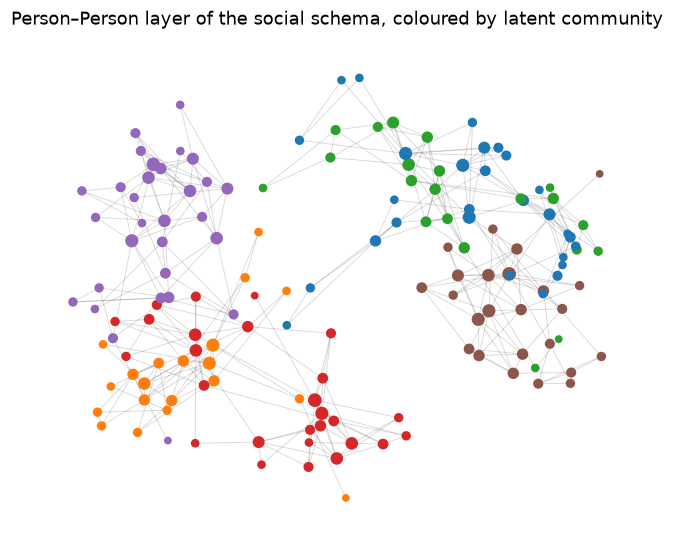

In [4]:
people = [n for n, d in G.nodes(data=True) if d["type"] == "Person"]
H = G.subgraph(people).to_undirected()
pos = nx.spring_layout(H, seed=7, k=0.35)
colors = [plt.cm.tab10(G.nodes[n]["community"] % 10) for n in H.nodes()]
fig, ax = plt.subplots(figsize=(7.5, 6))
nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.15, width=0.6)
nx.draw_networkx_nodes(H, pos, ax=ax, node_color=colors, node_size=[20 + 6 * H.degree(n) for n in H.nodes()], linewidths=0)
ax.set_title("Person–Person layer of the social schema, coloured by latent community"); ax.axis("off"); ax.grid(False)
plt.show()

## 2. The fraud pack: a synthetic bank

`fraud.generate` builds customers, accounts, merchants, devices and external counterparties, runs a legitimate transaction process over a period, then injects labelled typologies. `scale` follows Santander's gen-fraud-graph convention (`1.0` ≈ 10M accounts / 90M transactions); `0.002` is 20K accounts and ~180K transactions, a few seconds.

In [5]:
run = fraud.generate(scale=0.002, hardness="medium", seed=42, period_days=90)
print(run.manifest.model_dump_json(indent=2, exclude={"created_at"}))

{
  "schema_name": "fraud",
  "schema_digest": "f036c23bbd69559a",
  "seed": 42,
  "shard_size": 10000,
  "engine_version": "1",
  "graphfaker_version": "0.5.0",
  "node_counts": {
    "Customer": 14286,
    "Account": 20000,
    "Merchant": 400,
    "Device": 16428,
    "Counterparty": 40
  },
  "edge_counts": {
    "OWNS": 20000,
    "USES": 17434,
    "PAYS": 123389,
    "TRANSFERS": 49174,
    "WIRES": 6642
  },
  "extra": {
    "fraud": {
      "scale": 0.002,
      "hardness": "medium",
      "period_start": "2024-01-01",
      "period_days": 90,
      "locale": "en_US",
      "currency": "USD",
      "reporting_threshold": 10000.0,
      "patterns": null,
      "regions": 8
    }
  }
}


In [6]:
run.tables.nodes["Customer"].head(5)

id,name,date_of_birth,email,phone,street,city,segment,kyc_tier,log_income,activity,region
str,str,date,str,str,str,str,str,i64,f64,f64,i64
"""cust_0""","""Sheryl Stephens""",1965-06-07,"""salazarmaria@example.com""","""001-918-884-8530""","""82410 Robert Divide""","""East Bobbyborough""","""retail""",1,10.772,0.7213,2
"""cust_1""","""Lindsey Chang""",1963-03-16,"""larrybanks@example.net""","""(433)867-8592x258""","""6330 Amanda Landing""","""North Erikmouth""","""affluent""",3,10.858,1.1236,3
"""cust_2""","""James Johnson""",2003-07-04,"""adeleon@example.com""","""001-658-338-4029x6175""","""421 Andrew Corners Apt. 795""","""Jackfort""","""retail""",3,9.898,1.6523,7
"""cust_3""","""Melinda Bender""",1996-12-29,"""jennifersims@example.net""","""001-806-427-4505x432""","""66914 Miller Corner Suite 581""","""Harrismouth""","""affluent""",3,11.319,1.85,2
"""cust_4""","""Sara Roberson""",1972-06-13,"""davistanner@example.net""","""(778)983-7173""","""21164 Gonzalez Coves Suite 115""","""Dominguezmouth""","""retail""",1,11.697,2.4514,4


In [7]:
run.tables.nodes["Account"].head(5)

id,customer,account_type,status,currency,balance,region,opened_at
str,str,str,str,str,f64,i64,date
"""acc_0""","""cust_8185""","""checking""","""active""","""USD""",801.76,7,2023-07-10
"""acc_1""","""cust_12416""","""credit""","""active""","""USD""",5331.2,4,2023-10-13
"""acc_2""","""cust_1371""","""savings""","""active""","""USD""",472.89,7,2022-10-23
"""acc_3""","""cust_4604""","""checking""","""active""","""USD""",7054.99,5,2023-08-18
"""acc_4""","""cust_2996""","""checking""","""active""","""USD""",6178.1,4,2019-06-02


In [8]:
run.tables.edges["TRANSFERS"].head(5)

source,target,tx_id,timestamp,amount,memo,recurring
str,str,str,datetime[μs],f64,str,bool
"""acc_9562""","""acc_1213""","""tx_12""",2024-01-01 00:09:28,36.84,"""""",false
"""acc_13033""","""acc_8833""","""tx_14""",2024-01-01 00:15:26,269.92,"""thanks""",false
"""acc_9105""","""acc_10429""","""tx_17""",2024-01-01 00:24:17,91.54,"""gift""",false
"""acc_13731""","""acc_9268""","""tx_19""",2024-01-01 00:32:45,130.45,"""""",false
"""acc_13144""","""acc_11796""","""tx_30""",2024-01-01 00:52:56,120.24,"""""",false


## 3. What does the data look like?

Node tables per type, edge tables per relationship, all plain Polars frames. Start with the shape of the transaction layer: three channels (card payments to merchants, P2P transfers, wires to external counterparties), and a recurring component (salary, rent, utilities, subscriptions) underneath the ad-hoc activity.

In [9]:
tx = pl.concat([run.tables.edges[c].with_columns(pl.lit(c).alias("channel")) for c in ("PAYS", "TRANSFERS", "WIRES")])
tx.group_by("channel").agg(
    pl.len().alias("transactions"),
    pl.col("recurring").mean().round(3).alias("recurring_share"),
    pl.col("amount").median().round(2).alias("median_amount"),
    pl.col("amount").quantile(0.99).round(2).alias("p99_amount"),
).sort("transactions", descending=True)

channel,transactions,recurring_share,median_amount,p99_amount
str,u32,f64,f64,f64
"""PAYS""",123389,0.361,55.27,2293.57
"""TRANSFERS""",49174,0.182,159.93,12795.56
"""WIRES""",6642,0.0,1073.38,9908.63


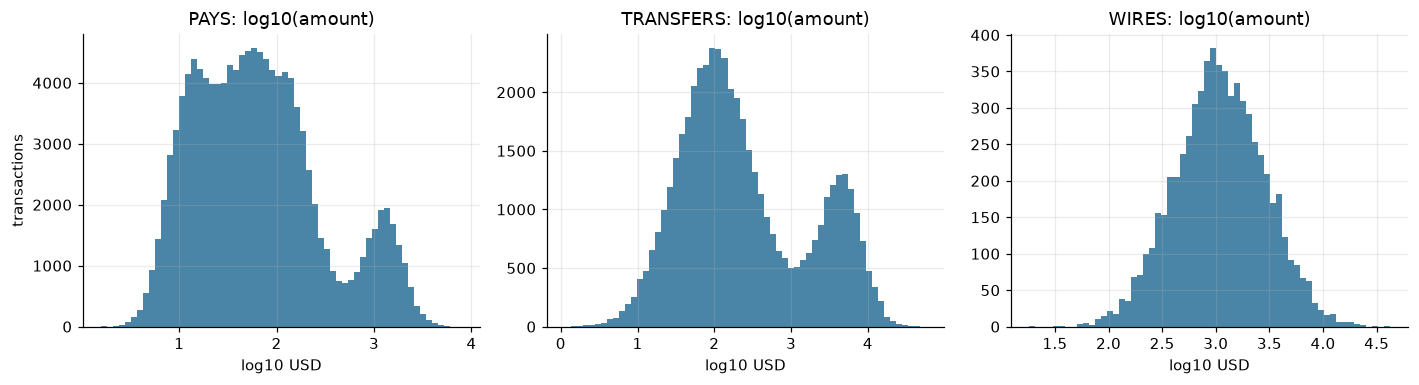

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, channel, color in zip(axes, ("PAYS", "TRANSFERS", "WIRES"), (ACCENT, ACCENT, ACCENT)):
    amounts = tx.filter(pl.col("channel") == channel)["amount"].to_numpy()
    ax.hist(np.log10(amounts), bins=60, color=color, alpha=0.85)
    ax.set_title(f"{channel}: log10(amount)"); ax.set_xlabel("log10 USD")
axes[0].set_ylabel("transactions")
plt.tight_layout(); plt.show()

Timing follows people, not a uniform random number: quiet nights, a lunchtime and an evening peak, quieter weekends, wires in business hours.

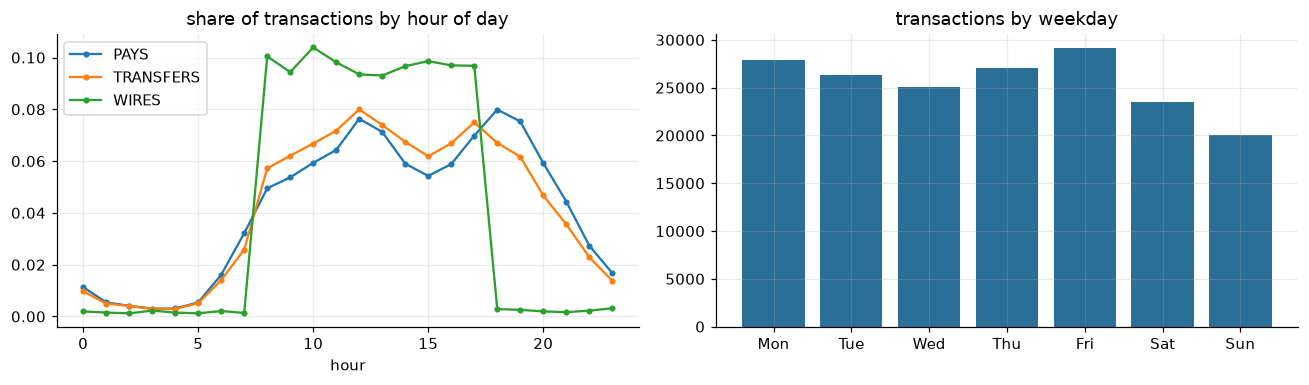

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
hours = tx.group_by(["channel", pl.col("timestamp").dt.hour().alias("hour")]).len().sort("hour")
for channel in ("PAYS", "TRANSFERS", "WIRES"):
    h = hours.filter(pl.col("channel") == channel)
    axes[0].plot(h["hour"], h["len"] / h["len"].sum(), marker="o", ms=3, label=channel)
axes[0].set_title("share of transactions by hour of day"); axes[0].set_xlabel("hour"); axes[0].legend()
days = tx.group_by(pl.col("timestamp").dt.weekday().alias("weekday")).len().sort("weekday")
axes[1].bar(days["weekday"], days["len"], color=ACCENT)
axes[1].set_xticks(range(1, 8)); axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_title("transactions by weekday")
plt.tight_layout(); plt.show()

Structure: a few merchants take most of the card traffic, and people transfer to the same handful of contacts again and again. That is what gives the P2P layer hubs, repeat partners and community structure instead of an Erdős–Rényi soup.

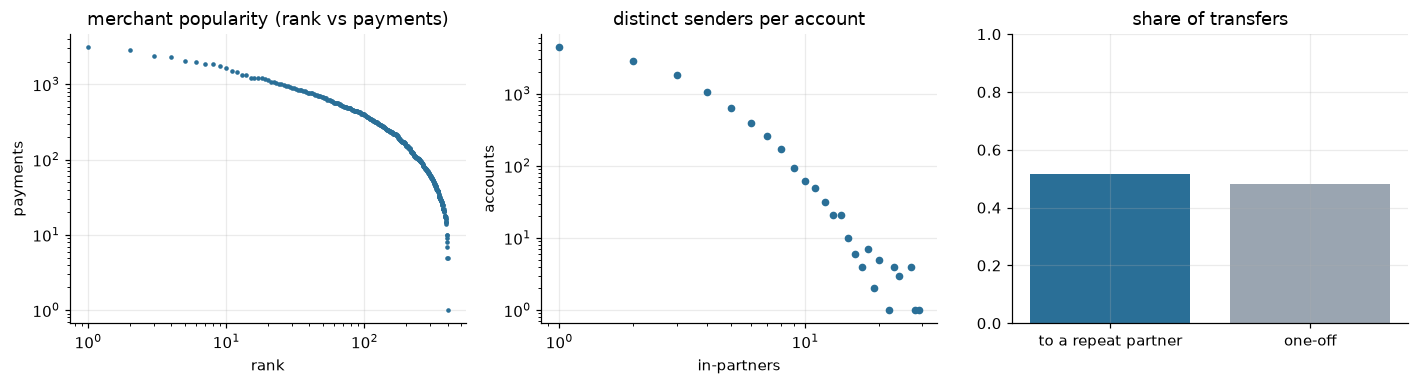

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
merchant_deg = run.tables.edges["PAYS"].group_by("target").len().sort("len", descending=True)["len"].to_numpy()
axes[0].loglog(np.arange(1, len(merchant_deg) + 1), merchant_deg, ".", color=ACCENT, ms=4)
axes[0].set_title("merchant popularity (rank vs payments)"); axes[0].set_xlabel("rank"); axes[0].set_ylabel("payments")

transfers = run.tables.edges["TRANSFERS"]
deg = transfers.group_by("target").agg(pl.col("source").n_unique().alias("k"))["k"].to_numpy()
values, counts = np.unique(deg, return_counts=True)
axes[1].loglog(values, counts, "o", color=ACCENT, ms=4)
axes[1].set_title("distinct senders per account"); axes[1].set_xlabel("in-partners"); axes[1].set_ylabel("accounts")

pairs = transfers.group_by(["source", "target"]).len()
repeat = float(pairs.filter(pl.col("len") > 1)["len"].sum() / transfers.height)
axes[2].bar(["to a repeat partner", "one-off"], [repeat, 1 - repeat], color=[ACCENT, LEGIT])
axes[2].set_title("share of transfers"); axes[2].set_ylim(0, 1)
plt.tight_layout(); plt.show()

Zoom in on one customer: the salary lands on payday, rent goes out on the first, subscriptions on their own day, and the rest is ad-hoc. This is the background a laundering pattern has to hide in.

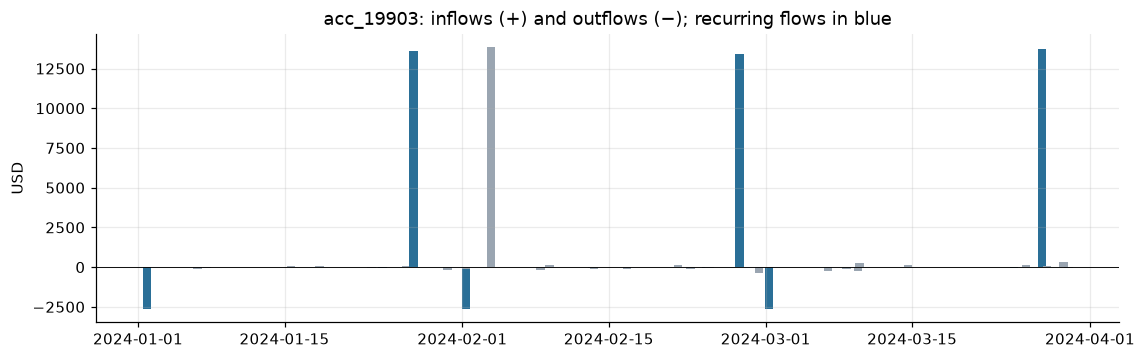

timestamp,channel,amount,memo,recurring
datetime[μs],str,f64,str,bool
2024-01-01 20:00:00,"""PAYS""",2632.26,"""""",true
2024-01-06 16:21:01,"""TRANSFERS""",100.92,"""rent share""",false
2024-01-07 14:21:37,"""TRANSFERS""",64.55,"""dinner""",false
2024-01-14 09:44:59,"""TRANSFERS""",30.39,"""""",false
2024-01-15 15:06:30,"""TRANSFERS""",52.59,"""invoice""",false
2024-01-18 08:21:55,"""TRANSFERS""",97.05,"""thanks""",false
2024-01-23 07:27:08,"""PAYS""",71.95,"""""",false
2024-01-24 09:00:00,"""PAYS""",34.76,"""""",true


In [13]:
accounts = run.tables.nodes["Account"]
salaried = transfers.filter(pl.col("memo") == "salary")["target"].value_counts().sort("count", descending=True)["target"][0]
mine = tx.filter((pl.col("source") == salaried) | (pl.col("target") == salaried)).sort("timestamp")
mine = mine.with_columns(pl.when(pl.col("target") == salaried).then(pl.col("amount")).otherwise(-pl.col("amount")).alias("signed"))
fig, ax = plt.subplots(figsize=(12, 3.4))
colors = [ACCENT if r else LEGIT for r in mine["recurring"]]
ax.bar(mine["timestamp"].to_list(), mine["signed"].to_list(), width=0.8, color=colors)
ax.axhline(0, color="black", lw=0.6)
ax.set_title(f"{salaried}: inflows (+) and outflows (−); recurring flows in blue"); ax.set_ylabel("USD")
plt.show()
mine.select(["timestamp", "channel", "amount", "memo", "recurring"]).head(8)

## 4. Ground truth

Every injected pattern is recorded with its typology, accounts and roles, and every transaction it created. The edge tables carry **no** labels; `tx_id`s are assigned in time order so the id does not leak what was injected. At `hardness="medium"`, decoys (legitimate payroll fan-outs, marketplace fan-ins, supplier cycles) are added and labelled *not* fraud.

In [14]:
patterns = run.truth["patterns"]
patterns.select(["pattern_id", "typology", "is_fraud", "n_accounts", "n_transactions", "start", "end"]).head(6)

pattern_id,typology,is_fraud,n_accounts,n_transactions,start,end
str,str,bool,i64,i64,datetime[μs],datetime[μs]
"""pat_0""","""fan_in""",true,10,9,2024-01-07 07:38:33,2024-01-12 19:55:36
"""pat_1""","""fan_in""",true,8,7,2024-01-11 05:04:06,2024-01-14 21:07:13
"""pat_2""","""fan_out""",true,12,11,2024-01-30 20:22:07,2024-02-02 09:05:48
"""pat_3""","""fan_out""",true,9,8,2024-03-11 23:41:16,2024-03-14 02:40:17
"""pat_4""","""gather_scatter""",true,12,11,2024-01-15 04:15:46,2024-01-21 16:23:11
"""pat_5""","""gather_scatter""",true,14,13,2024-02-08 15:34:16,2024-02-16 02:21:14


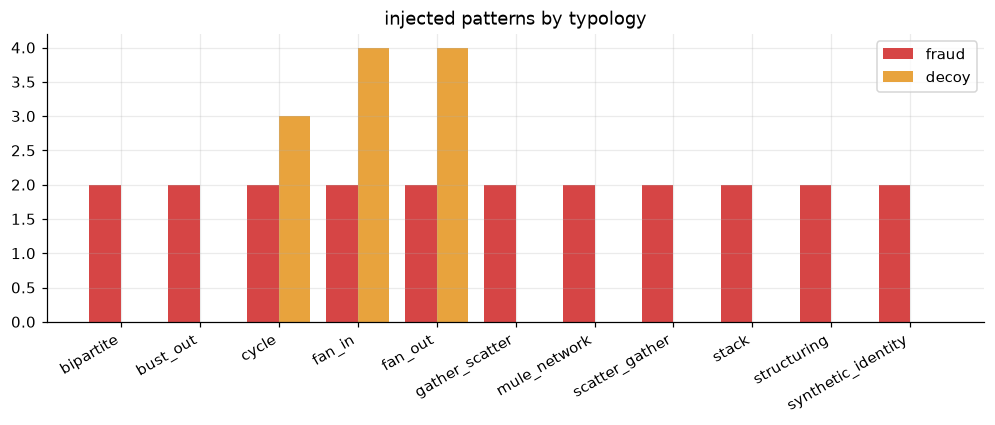

In [15]:
counts = patterns.group_by(["typology", "is_fraud"]).len().sort("typology")
fig, ax = plt.subplots(figsize=(11, 3.4))
typs = sorted(counts["typology"].unique().to_list())
for offset, flag, color, label in ((-0.2, True, FRAUD, "fraud"), (0.2, False, DECOY, "decoy")):
    sub = counts.filter(pl.col("is_fraud") == flag)
    values = {t: 0 for t in typs} | dict(zip(sub["typology"], sub["len"]))
    ax.bar(np.arange(len(typs)) + offset, [values[t] for t in typs], width=0.4, color=color, label=label)
ax.set_xticks(range(len(typs))); ax.set_xticklabels(typs, rotation=30, ha="right"); ax.legend(); ax.set_title("injected patterns by typology")
plt.show()

Draw a pattern in its neighbourhood: the pattern's own transactions in red, the accounts' legitimate activity in grey. A fan-in and a cycle:

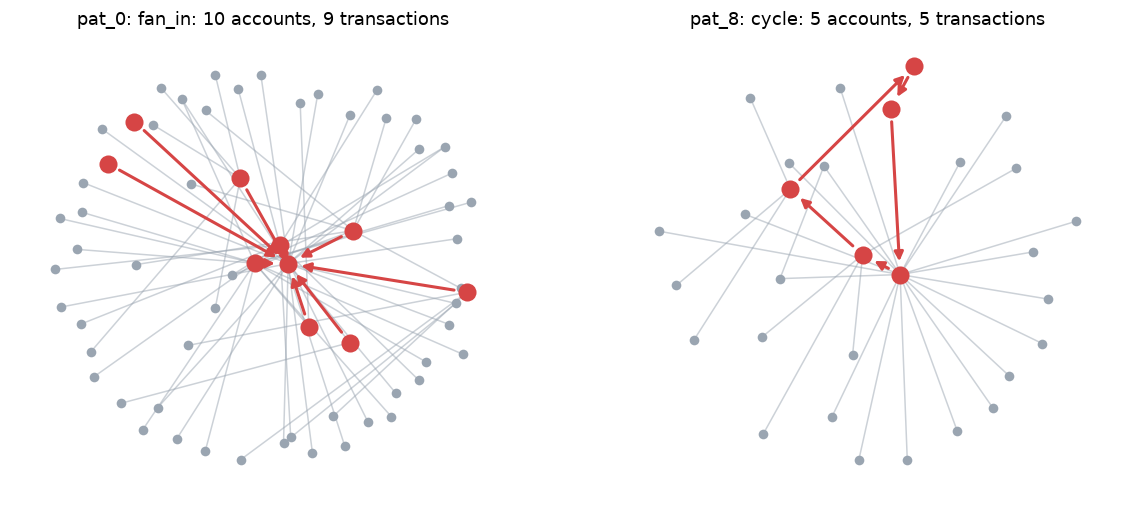

In [16]:
Gf = run.to_networkx()
tx_truth = run.truth["transactions"]

def draw_pattern(pattern_id, ax):
    row = patterns.filter(pl.col("pattern_id") == pattern_id).row(0, named=True)
    members = set(row["accounts"])
    own = tx.join(tx_truth.filter(pl.col("pattern_id") == pattern_id), on="tx_id")
    fraud_edges = set(zip(own["source"].to_list(), own["target"].to_list()))
    neighbours = {n for m in members for n in list(Gf.predecessors(m)) + list(Gf.successors(m)) if Gf.nodes[n]["type"] == "Account"}
    nodes = members | set(list(neighbours)[:60])
    S = Gf.subgraph(nodes)
    pos = nx.spring_layout(S, seed=3, k=0.9)
    legit = [(u, v) for u, v in S.edges() if (u, v) not in fraud_edges]
    guilty = [(u, v) for u, v in S.edges() if (u, v) in fraud_edges]
    nx.draw_networkx_edges(S, pos, edgelist=legit, ax=ax, edge_color=LEGIT, alpha=0.5, arrows=False)
    nx.draw_networkx_edges(S, pos, edgelist=guilty, ax=ax, edge_color=FRAUD, width=2, arrows=True, arrowsize=12)
    nx.draw_networkx_nodes(S, pos, nodelist=[n for n in S if n not in members], ax=ax, node_color=LEGIT, node_size=40, linewidths=0)
    nx.draw_networkx_nodes(S, pos, nodelist=list(members), ax=ax, node_color=FRAUD, node_size=140, linewidths=0)
    ax.set_title(f"{pattern_id}: {row['typology']}: {len(members)} accounts, {row['n_transactions']} transactions"); ax.axis("off"); ax.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
draw_pattern(patterns.filter((pl.col("typology") == "fan_in") & pl.col("is_fraud"))["pattern_id"][0], axes[0])
draw_pattern(patterns.filter((pl.col("typology") == "cycle") & pl.col("is_fraud"))["pattern_id"][0], axes[1])
plt.show()

Some typologies live off the transaction layer. Mule networks share a device; synthetic identities share phone and address. The same collisions happen innocently (households share tablets), which is what makes them a signal rather than a giveaway.

In [17]:
roles = run.truth["accounts"]
owners = run.tables.nodes["Account"].select(["id", "customer"]).rename({"id": "account_id"})
uses = run.tables.edges["USES"].rename({"source": "customer", "target": "device"})
mules = roles.filter(pl.col("role") == "mule").join(owners, on="account_id").join(uses, on="customer")
shared = mules.group_by(["pattern_id", "device"]).agg(pl.col("account_id").n_unique().alias("mules_on_device")).filter(pl.col("mules_on_device") > 1)
print("mule networks with a shared device:", shared["pattern_id"].n_unique(), "of", roles.filter(pl.col('role') == 'mule')['pattern_id'].n_unique())
households = uses.group_by("device").len().filter(pl.col("len") > 1).height
print("devices shared by ordinary customers (households):", households)
shared.head()

mule networks with a shared device: 2 of 2
devices shared by ordinary customers (households): 987


pattern_id,device,mules_on_device
str,str,u32
"""pat_16""","""dev_15025""",8
"""pat_17""","""dev_9951""",6


## 5. How hard is the fraud to find?

Hardness is not a claim, it is a measurement. For every typology, each single feature a simple rule might threshold on (amount, round amounts, proximity to the reporting threshold, degree, pass-through ratio, burstiness, account age) is scored by the AUC it achieves against the truth. Then the same run at `low`, `medium` and `high` hardness, to see what fades and what does not.

In [18]:
report = hardness_report(run)
print(report.summary())

hardness report: max single-feature AUC 0.990

level       typology            feature                   auc
transaction structuring         amount                  0.990
account     structuring         max_amount              0.966
account     bust_out            out_partners            0.933
account     mule_network        pass_through            0.916
account     stack               max_amount              0.915
account     bust_out            out_count               0.909
account     bust_out            out_amount              0.907
transaction stack               amount                  0.907


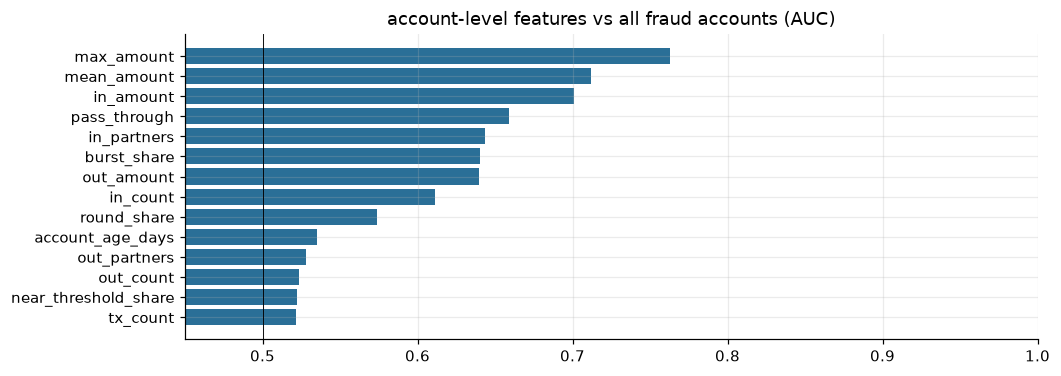

In [19]:
worst = report.accounts.filter(pl.col("typology") == "all").sort("auc", descending=True)
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.barh(worst["feature"].to_list()[::-1], worst["auc"].to_list()[::-1], color=[FRAUD if a > 0.8 else ACCENT for a in worst["auc"].to_list()[::-1]])
ax.axvline(0.5, color="black", lw=0.6); ax.set_xlim(0.45, 1.0); ax.set_title("account-level features vs all fraud accounts (AUC)")
plt.show()

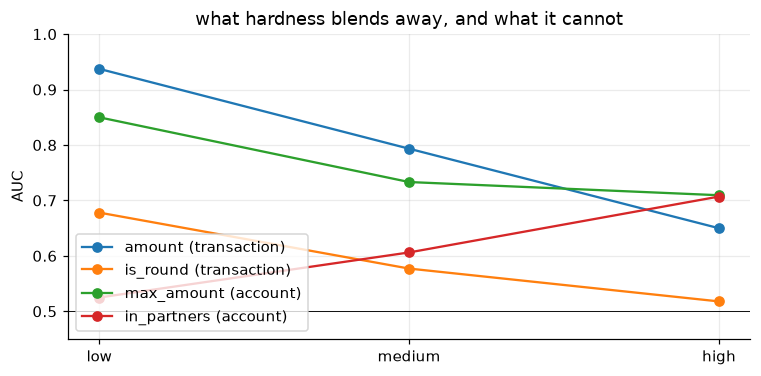

hardness,amount (transaction),is_round (transaction),max_amount (account),in_partners (account)
str,f64,f64,f64,f64
"""low""",0.937396,0.678098,0.849982,0.524826
"""medium""",0.793306,0.577088,0.733179,0.606176
"""high""",0.649799,0.517818,0.709363,0.707027


In [20]:
levels = {}
for level in ("low", "medium", "high"):
    r = fraud.generate(scale=0.001, hardness=level, seed=7)
    h = hardness_report(r)
    levels[level] = {
        "amount (transaction)": h.transactions.filter((pl.col("typology") == "all") & (pl.col("feature") == "amount"))["auc"][0],
        "is_round (transaction)": h.transactions.filter((pl.col("typology") == "all") & (pl.col("feature") == "is_round"))["auc"][0],
        "max_amount (account)": h.accounts.filter((pl.col("typology") == "all") & (pl.col("feature") == "max_amount"))["auc"][0],
        "in_partners (account)": h.accounts.filter((pl.col("typology") == "all") & (pl.col("feature") == "in_partners"))["auc"][0],
    }
table = pl.DataFrame({"hardness": list(levels)} | {k: [levels[l][k] for l in levels] for k in next(iter(levels.values()))})
fig, ax = plt.subplots(figsize=(8, 3.6))
for k in table.columns[1:]:
    ax.plot(table["hardness"], table[k], marker="o", label=k)
ax.axhline(0.5, color="black", lw=0.6); ax.set_ylim(0.45, 1.0); ax.set_ylabel("AUC"); ax.legend(loc="lower left"); ax.set_title("what hardness blends away, and what it cannot")
plt.show()
table

Amount and round-number signals fade as hardness rises. Degree does not: under the scale convention an account makes about nine transactions a quarter, so even a small ring is a local outlier. That is a property of the convention, reported rather than hidden, and it is the quantified argument for looking at structure.

## 6. Score a detector

`evaluate` scores flagged accounts and transactions against the truth at account, transaction and pattern level (a pattern counts as found when at least `ring_threshold` of its accounts are flagged), the way gen-fraud-graph's evaluator does. Two naive rules:

In [21]:
threshold = run.manifest.extra["fraud"]["reporting_threshold"]
near = transfers.filter((pl.col("amount") >= 0.85 * threshold) & (pl.col("amount") < threshold)).group_by("source").len().filter(pl.col("len") >= 3)["source"].to_list()
hubs = transfers.group_by("target").agg(pl.col("source").n_unique().alias("k")).filter(pl.col("k") >= 6)["target"].to_list()
print("rule A: three or more near-threshold transfers out\n" + evaluate(run, near, ring_threshold=0.5).summary().split("\n\n")[0])
print()
print("rule B: six or more distinct senders\n" + evaluate(run, hubs, ring_threshold=0.5).summary().split("\n\n")[0])

rule A: three or more near-threshold transfers out
level          precision  recall     f1     tp     fp     fn
account            0.022   0.025  0.023      3    133    118
transaction        0.000   0.000  0.000      0      0    246
pattern            1.000   0.091  0.167      2      0     20

rule B: six or more distinct senders
level          precision  recall     f1     tp     fp     fn
account            0.017   0.165  0.032     20   1124    101
transaction        0.000   0.000  0.000      0      0    246
pattern            1.000   0.045  0.087      1      0     21


Rule A's false positives are almost all business accounts whose "near-threshold transfers" are monthly salaries to well-paid staff: the payroll false positive every AML analyst knows, produced by the process rather than scripted. Rule B flags hubs: marketplaces, employers, popular people. Both find a couple of patterns and drown in noise, which is the case for looking at structure and context together, and what the ground truth lets you quantify.

## 7. Write it, read it back, query it

A run writes `nodes/`, `edges/`, `truth/`, `schema.yaml` and `manifest.json`. Parquet is the interchange format; it is what Neo4j's importer, LadybugDB/Kùzu `COPY`, Spark and PyTorch Geometric all read.

In [22]:
out = run.write(WORK / "bank")
for p in sorted(out.rglob("*")):
    if p.is_file(): print(f"{p.relative_to(out).as_posix():<32}{p.stat().st_size/1e6:7.2f} MB")

edges/OWNS.parquet                 0.15 MB
edges/PAYS.parquet                 1.77 MB
edges/TRANSFERS.parquet            1.04 MB
edges/USES.parquet                 0.11 MB
edges/WIRES.parquet                0.14 MB
manifest.json                      0.00 MB
nodes/Account.parquet              0.29 MB
nodes/Counterparty.parquet         0.00 MB
nodes/Customer.parquet             0.87 MB
nodes/Device.parquet               0.44 MB
nodes/Merchant.parquet             0.01 MB
schema.yaml                        0.00 MB
truth/accounts.parquet             0.00 MB
truth/patterns.parquet             0.01 MB
truth/region.parquet               0.00 MB
truth/transactions.parquet         0.00 MB


In [23]:
tables = GraphTables.read_parquet(out)
manifest = Manifest.read(out / "manifest.json")
schema_back = GraphSchema.from_yaml(out / "schema.yaml")
print(tables.node_count, "nodes,", tables.edge_count, "edges | schema digest matches:", schema_back.digest() == manifest.schema_digest)
# Polars on the tables: the busiest merchants by category
(tables.edges["PAYS"].join(tables.nodes["Merchant"].rename({"id": "target"}), on="target")
   .group_by("category").agg(pl.len().alias("payments"), pl.col("amount").sum().round(0).alias("volume"))
   .sort("volume", descending=True))

51154

 nodes, 216639 edges | schema digest matches: True


category,payments,volume
str,u32,f64
"""rent""",13477,1.8935368e7
"""utilities""",22082,3.417341e6
"""travel""",3075,1.847643e6
"""retail""",15474,1.673917e6
…,…,…
"""healthcare""",2569,498584.0
"""subscription""",30008,412488.0
"""fuel""",6815,355832.0
"""entertainment""",5185,203103.0


### Cypher on an embedded graph database

`load_directory` builds an embedded database from the files on disk, with the ground truth as a subgraph (`Pattern` nodes, `IN_PATTERN` memberships with roles, `is_fraud` on the money relationships), and verifies the load against the Parquet it came from. One file, no server. Needs a driver: `pip install ladybug` (`kuzu` still works, same API). From the command line this is `graphfaker load ladybug bank`.

In [24]:
from graphfaker.sinks import write_neo4j_admin
from graphfaker.sinks.ladybug import load_directory, verify_directory
from graphfaker.sinks.ladybug import _driver
try:
    driver = _driver()
except ImportError:
    driver = None
if driver is None:
    print("no driver installed: pip install ladybug to run the queries below")
else:
    report = load_directory(WORK / "bank", WORK / "bank.db")
    print(report.summary())
    print(verify_directory(WORK / "bank", WORK / "bank.db").summary())
    conn = driver.Connection(driver.Database(str(WORK / "bank.db")))

loaded into database 'C:\\Users\\Dee\\AppData\\Local\\Temp\\tmpylkis93y\\bank.db' in 4.3s (62,275 rows/s)
  nodes     51,154  Account=20000, Counterparty=40, Customer=14286, Device=16428, Merchant=400
  edges    216,639  OWNS=20000, PAYS=123389, TRANSFERS=49174, USES=17434, WIRES=6642
  truth        492  Pattern=33, IN_PATTERN=205, PAYS.is_fraud=31, TRANSFERS.is_fraud=215, WIRES.is_fraud=0, Region=8


PASS: 153/153 checks on C:\Users\Dee\AppData\Local\Temp\tmpylkis93y\bank.db


In [25]:
def cypher(q):
    res = conn.execute(q); cols = res.get_column_names(); rows = []
    while res.has_next(): rows.append(res.get_next())
    return pl.DataFrame(rows, schema=cols, orient="row") if rows else pl.DataFrame()

if driver:
    display(cypher('''
      MATCH (a:Account)-[t:TRANSFERS]->(b:Account)
      WHERE t.amount >= 8500 AND t.amount < 10000
      WITH a, count(t) AS near_threshold_transfers
      RETURN a.id AS account, near_threshold_transfers,
             EXISTS { MATCH (a)-[:IN_PATTERN]->(:Pattern {typology: 'structuring'}) } AS planted
      ORDER BY near_threshold_transfers DESC LIMIT 5'''))

account,near_threshold_transfers,planted
str,i64,bool
"""acc_15865""",9,false
"""acc_12622""",7,true
"""acc_16058""",7,false
"""acc_14044""",6,false
"""acc_14529""",6,false


In [26]:
if driver:
    rings = cypher('''
      MATCH (a:Account)-[:TRANSFERS]->(b:Account)-[:TRANSFERS]->(c:Account)-[:TRANSFERS]->(d:Account)-[:TRANSFERS]->(a)
      WHERE a.id < b.id AND a.id < c.id AND a.id < d.id
      RETURN a.id AS a, b.id AS b, c.id AS c, d.id AS d''')
    flagged = set(rings["a"]) | set(rings["b"]) | set(rings["c"]) | set(rings["d"]) if rings.height else set()
    print(f"4-cycles in the transfer graph: {rings.height}; accounts on one: {len(flagged)}")
    ev = evaluate(run, flagged, ring_threshold=0.5)
    print(ev.summary().split("\n\n")[0])
    print("pattern recall, cycle typology:", round(ev.per_typology.get("cycle").recall, 2) if "cycle" in ev.per_typology else "n/a")

4-cycles in the transfer graph: 640; accounts on one: 209
level          precision  recall     f1     tp     fp     fn
account            0.029   0.050  0.036      6    203    115
transaction        0.000   0.000  0.000      0      0    246
pattern            1.000   0.045  0.087      1      0     21
pattern recall, cycle typology: 0.5


With the truth in the graph, the answer sits one hop from the guess. The near-threshold senders above are mostly employers paying salaries; the planted structurers are further down the list. Who is in a ring, and in what role:

In [27]:
if driver:
    display(cypher('''
      MATCH (a:Account)-[m:IN_PATTERN]->(p:Pattern)
      WHERE p.is_fraud
      RETURN p.typology AS typology, m.role AS role, count(*) AS accounts
      ORDER BY typology, role''').head(12))

typology,role,accounts
str,str,i64
"""bipartite""","""source""",8
"""bipartite""","""target""",4
"""bust_out""","""buster""",2
"""cycle""","""hop""",7
…,…,…
"""fan_out""","""receiver""",19
"""gather_scatter""","""hub""",2
"""gather_scatter""","""receiver""",12
"""gather_scatter""","""source""",12


Cycles are everywhere in a real transfer graph. That is why a bare cycle query has low precision, and why decoys are labelled. Device sharing, which only exists off the transaction layer, is one Cypher hop away:

In [28]:
if driver:
    display(cypher('''
      MATCH (c:Customer)-[:USES]->(d:Device)<-[:USES]-(o:Customer)
      WHERE c.id < o.id
      WITH d, count(*) AS pairs
      RETURN d.id AS device, d.device_type AS type, pairs ORDER BY pairs DESC LIMIT 5'''))

device,type,pairs
str,str,i64
"""dev_15025""","""desktop""",36
"""dev_9951""","""mobile""",21
"""dev_8744""","""tablet""",15
"""dev_2476""","""mobile""",10
"""dev_178""","""mobile""",1


### NetworkX and Neo4j

`run.to_networkx()` is the object-graph view, useful for algorithms and drawing (as above). For Neo4j, `write_neo4j_admin` writes typed CSVs plus the `neo4j-admin database import` command; for gen-fraud-graph users, `write_gen_fraud_graph` writes their exact layout.

In [29]:
neo = write_neo4j_admin(tables, WORK / "neo4j")
print(open(neo / "import.sh").read())
print("largest weakly connected component:", max(len(c) for c in nx.weakly_connected_components(Gf)), "of", Gf.number_of_nodes(), "nodes")

#!/bin/sh
# run from this directory, with the database stopped
neo4j-admin database import full \
  --nodes=Account=nodes_Account.csv \
  --nodes=Counterparty=nodes_Counterparty.csv \
  --nodes=Customer=nodes_Customer.csv \
  --nodes=Device=nodes_Device.csv \
  --nodes=Merchant=nodes_Merchant.csv \
  --relationships=OWNS=rels_OWNS.csv \
  --relationships=PAYS=rels_PAYS.csv \
  --relationships=TRANSFERS=rels_TRANSFERS.csv \
  --relationships=USES=rels_USES.csv \
  --relationships=WIRES=rels_WIRES.csv \
  graphfaker



largest weakly connected component: 41842 of 51154 nodes


## Where this is going

- Vectorised person sampling so `scale=1.0` (10M accounts, 90M transactions) runs in minutes rather than an hour.
- RDF, PyTorch Geometric and a live Neo4j driver as sinks.
- Lifting the transaction process and the typology catalog into the schema so other domains (supply chain, claims,
telco) declare them the same way. Domains are already modular: `graphfaker domains` lists them and `docs/adding-a-domain.md` explains how to add one.

How generation works is in `docs/how-it-works.md` and `docs/fraud-generation.md`; the plan is in `docs/design/synthetic-at-scale.md`.